In [2]:
import pandas as pd 
import numpy as np 
import requests
import boto3
import pg8000
import json
import os 
import requests
from PIL import Image
from io import BytesIO
import math
from scipy.ndimage import label
import io
from skimage.color import rgb2lab
from pg8000.dbapi import DatabaseError, ProgrammingError
from dotenv import load_dotenv
from datetime import datetime, timedelta, time
import gc
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))
from radar_scraper import fetch_image
# --- S3 SETUP ---
BUCKET_NAME = "dsa3101-storm-tracking-tw08"

# create s3 client (this reads credentials from ~/.aws/credentials)
s3 = boto3.client("s3")


# helpers

In [ ]:
####################################################################################################
# helpers 
def get_secret(secret_arn):
    resp = secrets_client.get_secret_value(SecretId=secret_arn)
    return json.loads(resp['SecretString'])

def get_db_conn(secret_arn):
    global _db_conn
    if _db_conn:
        try:
            cur = _db_conn.cursor()
            cur.execute("SELECT 1;")
            cur.close()
            return _db_conn
        except Exception:
            _db_conn = None
    secret = get_secret(secret_arn)
    host = secret['host']
    dbname = secret['dbname']
    user = secret['username']
    password = secret['password']
    port = int(secret.get('port', 5432))
    _db_conn = pg8000.connect(
        host=host,
        database=dbname,
        user=user,
        password=password,
        port=port
    )
    return _db_conn

def query_to_df(conn, query, params=None):
    """
    Execute an SQL query and return results as a pandas DataFrame.

    Args:
        conn : active pg8000 connection
        query : SQL query string (use %s placeholders)
        params : tuple/list of parameters (optional)
    """
    with conn.cursor() as cur:
        cur.execute(query, params or ())
        # Extract column names from cursor description
        columns = [desc[0] for desc in cur.description]
        data = cur.fetchall()
    # Create DataFrame
    return pd.DataFrame(data, columns=columns)

def upload_to_s3(bucket, key, data):
    s3.put_object(Bucket=bucket, Key=key, Body=data) # overwrites by default

def insert_metadata(conn, ts, range_km, url, s3_key, status='ok'):
    with conn.cursor() as cur:
        cur.execute("""
            INSERT INTO radar_image (
                timestamp, 
                range_km, 
                url, 
                s3_key, 
                status
            )
            VALUES (%s, %s, %s, %s, %s)
            ON CONFLICT (timestamp) DO UPDATE SET s3_key = EXCLUDED.s3_key, status = EXCLUDED.status,url = EXCLUDED.url;
        """, (ts, range_km, url, s3_key, status)) 
        conn.commit()




In [3]:
# Load environment variables from .env file
load_dotenv()

# Read credentials
DB_HOST = os.getenv("DB_HOST")
DB_PORT = int(os.getenv("DB_PORT", 5432))
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")

# Create connection
conn = pg8000.connect(
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    user=DB_USER,
    password=DB_PASS
)

print("✅ Connected successfully to PostgreSQL!")

✅ Connected successfully to PostgreSQL!


In [4]:
def fetch_s3_bytes(s3_key):
    try:
        obj = s3.get_object(Bucket=BUCKET_NAME, Key=s3_key)
        return obj['Body'].read()   # byte data
    except Exception as e:
        print(f"Error fetching {s3_key}: {e}")
        return None

# main backfil

In [45]:
query = """
    SELECT
        distinct(timestamp::date) as date_range

    FROM radar_image 
    order by 1 asc
    """
    
df = query_to_df(conn,query)

# convert to datetime
df['date_converted'] = pd.to_datetime(df['date_range'])

# lead the converted date by 1 (next row)
df['next_date'] = df['date_converted'].shift(-1)

# compute the day difference
df['diff_days'] = (df['next_date'] - df['date_converted']).dt.days


# filter rows with gaps > 1 day
gap_df = df[df['diff_days'] > 1]

gap_df


,date_range,date_converted,next_date,diff_days


In [44]:
query = """
    SELECT
        *
    FROM radar_image 
    where 
        status = 'missing'
    order by 2 asc
    
    """
    
df = query_to_df(conn,query)
print(df)

    image_id           timestamp  range_km  \
0        833 2025-09-23 09:55:00        70   
1        834 2025-09-23 10:00:00        70   
2        287 2025-09-25 12:25:00        70   
3        288 2025-09-25 12:30:00        70   
4        289 2025-09-25 12:35:00        70   
..       ...                 ...       ...   
56     39723 2025-10-15 11:35:00        70   
57     39725 2025-10-15 11:40:00        70   
58     39730 2025-10-15 11:50:00        70   
59     39724 2025-10-15 11:55:00        70   
60     39788 2025-10-15 16:15:00        70   

                                                  url s3_key   status  
0   https://www.nea.gov.sg/docs/default-source/rai...   None  missing  
1   https://www.nea.gov.sg/docs/default-source/rai...   None  missing  
2   https://www.nea.gov.sg/docs/default-source/rai...   None  missing  
3   https://www.nea.gov.sg/docs/default-source/rai...   None  missing  
4   https://www.nea.gov.sg/docs/default-source/rai...   None  missing  
..             

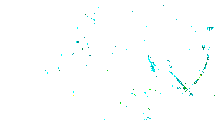

In [27]:
s3_key = "radar/2025/10/07/0900.png"   # full path in bucket
data = fetch_s3_bytes(s3_key)

image_buffer = BytesIO(data)

img = Image.open(image_buffer)
display(img)



In [37]:
conn.rollback()

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta

# days
start_date_str = "2025-08-02"
end_date_str   = "2025-08-02"
# end_date_str   = "2025-10-07"

start_date = datetime.strptime(start_date_str, "%Y-%m-%d").date()
end_date   = datetime.strptime(end_date_str, "%Y-%m-%d").date()

RANGE_KM = 70
MAX_WORKERS = 8  

current_date = start_date
while current_date <= end_date:
    run_date_str = current_date.strftime('%Y-%m-%d')
    print(f'pulling full day: {run_date_str}')

    # 5-min timeline for the entire day
    timeline = []
    day_start = datetime.combine(current_date, datetime.min.time())
    for h in range(24):
        for m in range(0, 60, 5):
            timeline.append(day_start + timedelta(hours=h, minutes=m))

    # accumulate db rows for the whole day
    db_rows = []  # each: (timestamp, range_km, url, s3_key, status)

    # parallel block: fetch + S3 upload per timestamp
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = []
        for ts in timeline:
            ts_str = ts.strftime("%Y%m%d%H%M")
            url    = f"https://www.nea.gov.sg/docs/default-source/rain-area/dpsri_{RANGE_KM}km_{ts_str}0000dBR.dpsri.png"
            s3_key = f"radar/{ts.strftime('%Y/%m/%d/%H%M')}.png"

            # small inline callable; fetch -> upload -> return db row tuple
            def _task(ts=ts, url=url, s3_key=s3_key):
                try:
                    img = fetch_image(url)
                    upload_to_s3(BUCKET_NAME, s3_key, img)

                    # success row
                    return (ts, RANGE_KM, url, s3_key, 'ok')
                except requests.exceptions.HTTPError:
                    # missing on source; still record status so downstream knows
                    return (ts, RANGE_KM, url, None, 'missing')
                except Exception as e:
                    # network hiccup or s3 error record as missing
                    print(f"warn: {ts} failed with {e}")
                    return (ts, RANGE_KM, url, None, 'missing')

            futures.append(ex.submit(_task))

        for fut in as_completed(futures):
            db_rows.append(fut.result())

    # single batch write to sql
    sql = """
    INSERT INTO radar_image (timestamp, range_km, url, s3_key, status)
    VALUES (%s, %s, %s, %s, %s)
    ON CONFLICT (timestamp)
    DO UPDATE SET
      range_km = EXCLUDED.range_km,
      url      = EXCLUDED.url,
      s3_key   = EXCLUDED.s3_key,
      status   = EXCLUDED.status;
    """
    try:
        with conn.cursor() as cur:
            cur.executemany(sql, db_rows)
        conn.commit()
        ok = sum(1 for _,_,_,k,st in db_rows if st == 'ok' and k)
        miss = len(db_rows) - ok
        print(f" day {run_date_str}: inserted {len(db_rows)} rows ({ok} ok, {miss} missing)")
    except Exception as e:
        conn.rollback()
        print(f" DB batch insert failed for {run_date_str}: {e}")
        raise

    current_date += timedelta(days=1)

pulling full day: 2025-08-02
 day 2025-08-02: inserted 288 rows (288 ok, 0 missing)
